# Phase 3 — Clinically gated fusion (Model D)

## The hypothesis

Concatenation (Model C) lets the head add clinical evidence to image evidence. It cannot express
the thing we actually believe: that clinical measurements change **how the scan should be read**.
A high CST means macular thickening, which should raise the weight the model puts on
fluid-related image features — a *multiplicative* interaction, not an additive one.

```
OCT   -> image encoder    -> image embedding ---------+
                                                       -> gated fusion -> multilabel head
BCVA/CST -> clinical encoder -> clinical embedding ---+
```

with

```
gate   = sigmoid(MLP(clinical_embedding))
scale  = 1 + alpha * (2 * gate - 1)      # residual: 1.0 means no modulation
gated  = image_embedding * scale
fused  = concat(gated, clinical_embedding)
```

## The failure mode this is built to avoid

A gate initialised carelessly collapses toward zero and erases the OCT signal before the image
encoder has learned anything. `ClinicalGate` zeroes its output weights and sets the bias so the
scale starts at **exactly 1.0** — a pure pass-through the model must learn to move away from.

## The question that decides whether this worked

Beating Model C on a metric is not enough. If the gate stayed at identity, or collapsed to a
constant the head could have absorbed into a bias, then Model D *is* Model C with extra
parameters and any difference is noise. Section 5 tests that directly.

---
## 1. Setup

In [1]:
%pip install -q -U \
    pandas \
    pyarrow \
    pyyaml \
    pillow \
    scikit-learn \
    scipy \
    matplotlib \
    seaborn \
    tqdm

In [2]:
%pip install -q -e /content/ClinBioGate --no-deps

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for olives-biomarkers (pyproject.toml) ... done


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyarrow
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NumPy: 2.1.3
Pandas: 3.0.5
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [4]:
from pathlib import Path
import subprocess

REPO_ROOT = Path("/content/ClinBioGate")

if not (REPO_ROOT / "pyproject.toml").is_file():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

print("Repository:", REPO_ROOT)
print("pyproject exists:", (REPO_ROOT / "pyproject.toml").is_file())

Repository: /content/ClinBioGate
pyproject exists: True


In [5]:
REPO_ROOT = Path("/content/ClinBioGate").resolve()

if not (REPO_ROOT / "pyproject.toml").is_file():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

In [6]:
REPO_ROOT = Path("/content/ClinBioGate").resolve()

if not (REPO_ROOT / "pyproject.toml").is_file():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

In [7]:
import os
import sys
import subprocess
import importlib
from pathlib import Path

# Confirm this notebook is attached to a Colab Linux runtime.
try:
    import google.colab
except ImportError as error:
    raise RuntimeError(
        f"This is not a Colab kernel. Active Python: {sys.executable}"
    ) from error

print("Active Python:", sys.executable)

if not sys.executable.startswith("/"):
    raise RuntimeError(
        "A Windows Python environment is active instead of the Colab kernel: "
        f"{sys.executable}"
    )

# Mount persistent dataset/output storage.
from google.colab import drive

drive.mount("/content/drive")

# Clone the code into Colab's temporary filesystem.
REPO_ROOT = Path("/content/ClinBioGate")

if not (REPO_ROOT / "pyproject.toml").is_file():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

assert (REPO_ROOT / "pyproject.toml").is_file()
assert (
    REPO_ROOT / "src" / "olives_biomarkers" / "__init__.py"
).is_file()

# Make the src-layout package importable directly.
os.chdir(REPO_ROOT)

SRC_DIR = str(REPO_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

importlib.invalidate_caches()

import olives_biomarkers

print("Repository:", REPO_ROOT)
print("Package:", olives_biomarkers.__file__)

Active Python: /usr/bin/python3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repository: /content/ClinBioGate
Package: /content/ClinBioGate/src/olives_biomarkers/__init__.py


In [8]:
from olives_biomarkers import (
    ExperimentRunner,
    ExperimentSuite,
    OlivesPipeline,
    ResultsAggregator,
    RunResult,
)
from olives_biomarkers.config import ConfigLoader
from olives_biomarkers.evaluation import GateAnalyzer, ResultsPlotter

In [9]:
# %load_ext autoreload
# %autoreload 2

import sys, warnings, time
from pathlib import Path

REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
sys.path.insert(0, str(REPO_ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from olives_biomarkers import (
    ExperimentRunner, ExperimentSuite, OlivesPipeline, ResultsAggregator, RunResult,
)
from olives_biomarkers.config import ConfigLoader
from olives_biomarkers.evaluation import GateAnalyzer, ResultsPlotter

pipeline = OlivesPipeline.from_config(REPO_ROOT / "configs" / "data.yaml", repo_root=REPO_ROOT)
loader = ConfigLoader(REPO_ROOT)

BUDGET = "colab_gpu" if pipeline.env.device == "cuda" else "local_cpu"
budget = loader.load(REPO_ROOT / "configs" / f"{BUDGET}.yaml")
RUNS_DIR = REPO_ROOT / "outputs" / "runs" / BUDGET
FIGURES = REPO_ROOT / "outputs" / "figures" / "phase3"
FIGURES.mkdir(parents=True, exist_ok=True)

plotter = ResultsPlotter()

def show(figure, name):
    if figure is None:
        print(f"(no figure for {name})")
        return
    plotter.save(figure, FIGURES / f"{name}.png")
    plt.show()

print(f"device={pipeline.env.device}  budget={BUDGET}  runs={RUNS_DIR}")

device=cuda  budget=colab_gpu  runs=/content/ClinBioGate/outputs/runs/colab_gpu


In [10]:
manifest = pipeline.get_manifest()
frame = pipeline.modelling_frame(manifest, attach_cache=True)
assignment = pipeline.make_holdout_split(manifest, write=False)   # identical to Phase 2
n_labels = len(manifest.label_columns)

print(f"{len(frame):,} scans | {frame.patient_id.nunique()} patients | {n_labels} labels")
print({k: len(v) for k, v in assignment.partitions.items()})

14:56:28 | INFO    | olives.manifest | Building manifest: config=disease_classification split=train shards=32 hashes=True
14:56:39 | INFO    | olives.manifest |   shard  1/32 train-00000-of-00032.parquet     rows=2464
14:56:50 | INFO    | olives.manifest |   shard  2/32 train-00001-of-00032.parquet     rows=2464
14:56:59 | INFO    | olives.manifest |   shard  3/32 train-00002-of-00032.parquet     rows=2464
14:57:06 | INFO    | olives.manifest |   shard  4/32 train-00003-of-00032.parquet     rows=2464
14:57:12 | INFO    | olives.manifest |   shard  5/32 train-00004-of-00032.parquet     rows=2464
14:57:19 | INFO    | olives.manifest |   shard  6/32 train-00005-of-00032.parquet     rows=2464
14:57:25 | INFO    | olives.manifest |   shard  7/32 train-00006-of-00032.parquet     rows=2463
14:57:32 | INFO    | olives.manifest |   shard  8/32 train-00007-of-00032.parquet     rows=2463
14:57:39 | INFO    | olives.manifest |   shard  9/32 train-00008-of-00032.parquet     rows=2463
14:57:49 | INF

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

---
## 2. The gate at initialisation

Before training anything, confirm the safety property holds: the applied scale must be 1.0 for
every sample and every channel, so the model starts as an exact copy of the ungated path.

In [ ]:
from olives_biomarkers.models import ModelFactory

cfg_gated = loader.load(REPO_ROOT / "configs" / "fusion_gated.yaml")
probe = ModelFactory().build(cfg_gated.model, n_labels=n_labels, clinical_dim=4)

stats = probe.gate_statistics(torch.randn(256, 4))
display(pd.Series(stats).to_frame("value").round(5))

assert abs(stats["scale_mean"] - 1.0) < 0.02, "gate is not an identity at init"
assert stats["scale_std"] < 1e-4, "gate varies at init; it should be a constant pass-through"
print("\nOK - the gate starts as an exact identity, so the OCT signal cannot be erased "
      "before training begins.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 218MB/s]


,value
gate_mean,0.5000
gate_std,0.0000
gate_min,0.5000
gate_max,0.5000
scale_mean,1.0000
scale_std,0.0000
scale_min,1.0000
scale_max,1.0000
fraction_scale_below_0.1,0.0000



OK - the gate starts as an exact identity, so the OCT signal cannot be erased before training begins.


In [ ]:
# And the gradient still flows, so the zeroed initialisation is not a dead end.
from olives_biomarkers.training.losses import MaskedBCEWithLogitsLoss

probe.train()
loss = MaskedBCEWithLogitsLoss()(
    probe(image=torch.randn(4, 3, 64, 64), clinical=torch.randn(4, 4)),
    torch.randint(0, 2, (4, n_labels)).float(),
)
loss.backward()
gate_grad = probe.gate.projection[-1].weight.grad
print(f"gate output-layer gradient magnitude: {gate_grad.abs().sum():.6f}")
assert gate_grad.abs().sum() > 0, "no gradient reaches the gate - it can never learn"
print("OK - the gate can learn away from identity.")

gate output-layer gradient magnitude: 1.844035
OK - the gate can learn away from identity.


---
## 3. Training Model D

Same split, same budget, same seeds as Phase 2. Nothing else may differ, or the comparison is
not a comparison.

In [ ]:
def make_config(stem):
    cfg = loader.load(REPO_ROOT / "configs" / f"{stem}.yaml")
    cfg.data.image_size = budget.data.image_size
    cfg.data.num_workers = budget.data.num_workers
    cfg.training.epochs = budget.training.epochs
    cfg.training.batch_size = budget.training.batch_size
    cfg.training.learning_rate = budget.training.learning_rate
    cfg.training.early_stopping_patience = budget.training.early_stopping_patience
    cfg.training.amp = budget.training.amp
    return cfg

SEEDS = [42] if BUDGET == "local_cpu" else [42, 43, 44]
RUN_TRAINING = True    # False -> load the runs saved by scripts/run_comparison.py

if RUN_TRAINING:
    suite = ExperimentSuite(pipeline, output_root=RUNS_DIR)
    gated_results = suite.run_models(
        configs={"gated_fusion": make_config("fusion_gated")},
        assignment=assignment,
        manifest=manifest,
        seeds=SEEDS,
    )
else:
    gated_results = [
        r for r in RunResult.load_all(RUNS_DIR) if r.model_name == "gated_fusion"
    ]
print(f"{len(gated_results)} gated-fusion run(s)")

12:29:35 | WARNING | olives.pipeline | image cache not found at /content/ClinBioGate/data/processed/images_labelled; call export_image_cache() for much faster training
12:29:35 | INFO    | olives.experiment | === gated_fusion | seed 42 | split holdout ===
12:29:36 | WARNING | olives.experiment | no image cache found; reading images straight from parquet, which is much slower. Run ImageCacheExporter once to avoid this.
12:29:36 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
12:29:36 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
12:29:36 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
12:29:36 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
12:29:36 | INFO    | olives.dataset | partition 'calibration': 882 rows, 9 patients
12:29:36 | INFO    | olives.experiment | run gated_fusion_holdout_seed42 | model=gated_fusion | 11429664 trainable params | devi

In [ ]:
# Bring in the Phase 2 baselines for the comparison.
all_results = RunResult.load_all(RUNS_DIR)
print(f"{len(all_results)} runs total: {sorted({r.model_name for r in all_results})}")

aggregator = ResultsAggregator(all_results)
comparison = aggregator.comparison(sort_by="macro_auprc")
comparison[["model", "seed", "n_parameters", "epochs_run", "minutes",
            "macro_f1", "macro_auroc", "macro_auprc"]]

3 runs total: ['gated_fusion']


,model,seed,n_parameters,epochs_run,minutes,macro_f1,macro_auroc,macro_auprc
0,gated_fusion,43,11429664,25,0.0000,0.5128,0.8524,0.5506
1,gated_fusion,44,11429664,20,0.0000,0.4822,0.8600,0.5399
2,gated_fusion,42,11429664,33,0.0000,0.4988,0.8528,0.5335


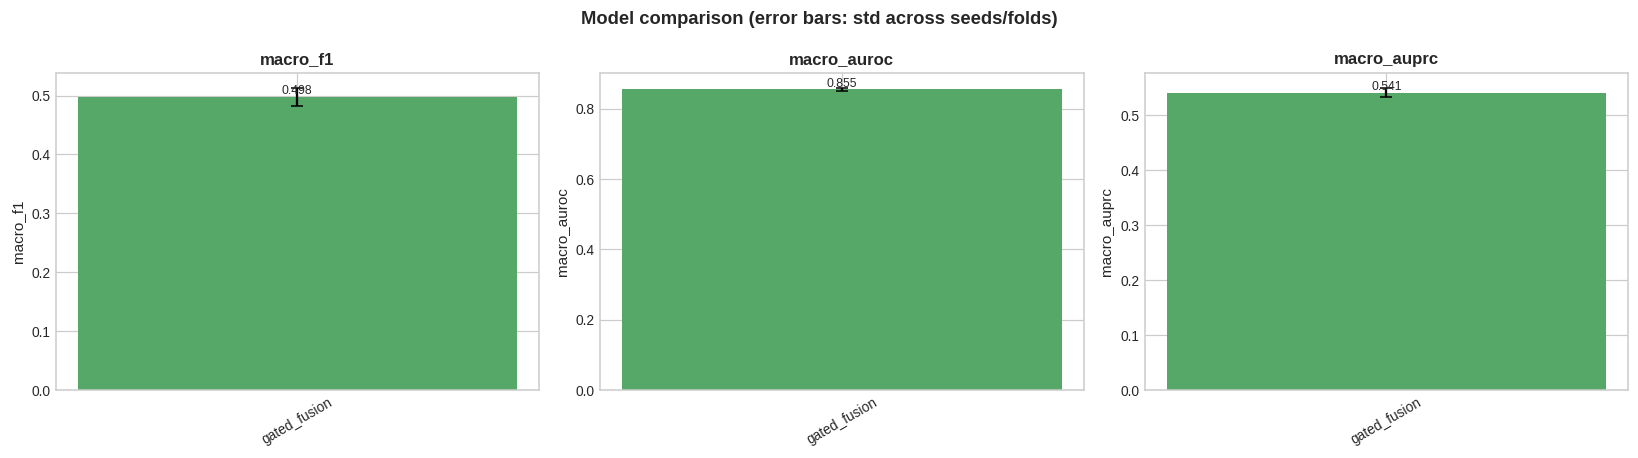

In [ ]:
show(plotter.model_comparison(comparison), "01_all_models")

---
## 4. Does D beat C?

The comparison that matters is gated fusion against **concatenation**, not against the OCT
baseline: both C and D see the clinical features, so C is what isolates the contribution of
*gating* specifically.

In [ ]:
means = comparison.groupby("model")[["macro_f1", "macro_auroc", "macro_auprc"]].mean()
display(means.round(4))

if {"concat_fusion", "gated_fusion"}.issubset(means.index):
    delta = means.loc["gated_fusion"] - means.loc["concat_fusion"]
    print("\nGated fusion minus concatenation:")
    for metric, value in delta.items():
        print(f"  {metric:>14}: {value:+.4f}")
    print("\nParameter cost of the gate:")
    params = comparison.groupby("model")["n_parameters"].first()
    extra = params.get("gated_fusion", 0) - params.get("concat_fusion", 0)
    print(f"  {extra:+,} parameters ({100 * extra / params.get('concat_fusion', 1):+.1f}%)")
    print("\nA point-estimate gap is not yet a result. Phase 5 checks whether the patient-level")
    print("confidence intervals actually separate.")

,macro_f1,macro_auroc,macro_auprc
model,,,
gated_fusion,0.4979,0.8551,0.5413


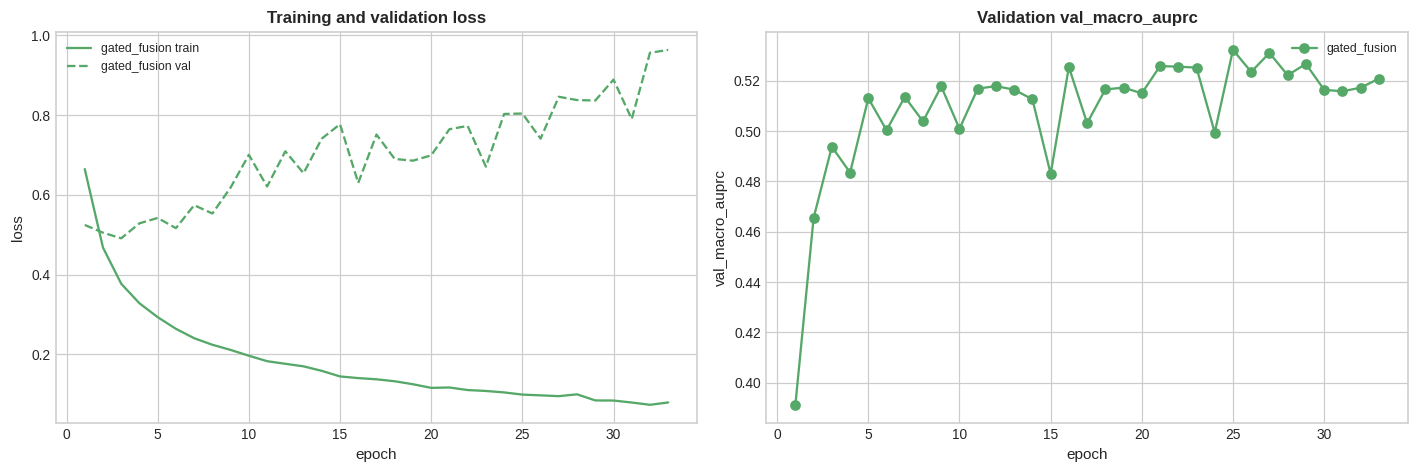

In [ ]:
histories = {
    r.model_name: r.history.to_frame()
    for r in all_results
    if r.seed == SEEDS[0] and len(r.history.records)
}
show(plotter.training_curves(histories, monitor="val_macro_auprc"), "02_training_curves")

---
## 5. What did the gate actually learn?

This is the section that decides whether Model D is a real mechanism or an expensive
re-parameterisation of Model C.

Three checks:

1. **Did it move?** Mean `|scale - 1|` near zero means the gate never left identity.
2. **Does it respond to input?** If per-channel standard deviation across samples is ~0, the gate
   is a learned constant that the classification head could have absorbed into its bias.
3. **Does it respond to the *right* input?** The gate should correlate with BCVA/CST, and should
   separate the fluid biomarkers more than the vitreous-face ones.

In [ ]:
runner = ExperimentRunner(pipeline, make_config("fusion_gated"), output_root=RUNS_DIR)
data = runner.build_data_module(frame, assignment, manifest.label_columns)

gated_run = next((r for r in all_results if r.model_name == "gated_fusion"), None)
assert gated_run is not None, "no gated-fusion run found; train one first"

model = ModelFactory().build(
    make_config("fusion_gated").model, n_labels=n_labels, clinical_dim=data.preprocessor.output_dim
)
from olives_biomarkers.training.callbacks import CheckpointManager

CheckpointManager(gated_run.run_dir / "checkpoints", run_id=gated_run.run_id).load(
    model, map_location=pipeline.env.device
)
print(f"loaded trained weights from {gated_run.run_id}")

16:45:01 | WARNING | olives.experiment | no image cache found; reading images straight from parquet, which is much slower. Run ImageCacheExporter once to avoid this.
16:45:01 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
16:45:01 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
16:45:01 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
16:45:01 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
16:45:01 | INFO    | olives.dataset | partition 'calibration': 882 rows, 9 patients
16:45:02 | INFO    | olives.callbacks | loaded checkpoint gated_fusion_holdout_seed42_best.pt (epoch 25)
loaded trained weights from gated_fusion_holdout_seed42


In [ ]:
analyzer = GateAnalyzer(model, device=pipeline.env.device)
collected = analyzer.collect(data.dataloader("test", shuffle=False))
summary = analyzer.summary(collected)
display(pd.Series(summary).to_frame("value").round(5))

print("\nInterpretation:")
notes = analyzer.interpret(summary)
if notes:
    for note in notes:
        print(f"  - {note}")
else:
    print("  - The gate moved off identity and varies with input, without collapsing.")

,value
gate_mean,0.9486
gate_std_overall,0.0976
gate_std_across_samples_mean,0.0199
gate_std_across_samples_max,0.0688
scale_mean,1.8971
scale_min,0.0762
scale_max,1.9999
fraction_channels_essentially_constant,0.2031
fraction_scale_suppressing,0.0074
fraction_scale_amplifying,0.9778



Interpretation:
  - The gate moved off identity and varies with input, without collapsing.


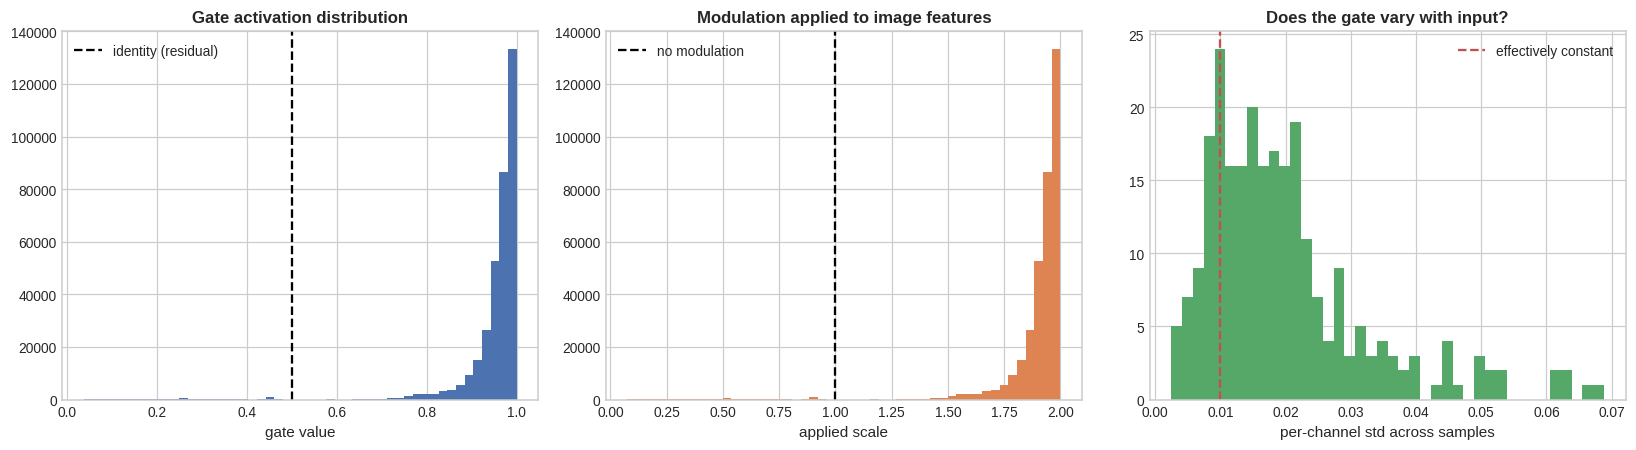

In [ ]:
show(plotter.gate_distribution(collected), "03_gate_distribution")

In [ ]:
# Does the gate respond to the clinical features it is conditioned on?
feature_names = data.preprocessor.feature_names
display(analyzer.clinical_response(collected, feature_names))
print("A gate that is genuinely clinically driven shows non-trivial correlation with at least")
print("one clinical feature. Near-zero everywhere means it is conditioning on nothing.")

,feature,spearman_r,p_value,note
0,bcva,-0.3875,0.0000,responds
1,cst,0.8768,0.0000,responds
2,bcva_missing,NaN,NaN,constant
3,cst_missing,NaN,NaN,constant


A gate that is genuinely clinically driven shows non-trivial correlation with at least
one clinical feature. Near-zero everywhere means it is conditioning on nothing.


In [ ]:
# Does gating separate the biomarkers CST should inform?
gate_by_label = analyzer.gate_by_label(collected, manifest.label_columns)
display(gate_by_label)
print("EDA predicted CST tracks the fluid biomarkers (irf, drt_me, srf). If the gate is doing")
print("clinically sensible work, those should sit near the top of this table rather than")
print("pavf/favf, which concern structure above the retina that CST does not measure.")

,label,n_present,gate_present,gate_absent,delta,cohens_d
0,drt_me,514,0.9635,0.9396,0.0238,1.3070
1,srf,51,0.9705,0.9477,0.0228,1.2510
2,rpe_disruption,1,0.9314,0.9486,-0.0171,-0.9400
3,irf,711,0.9564,0.9401,0.0163,0.8960
4,shrm,20,0.9641,0.9483,0.0157,0.8640
5,irhrf,973,0.9522,0.9397,0.0124,0.6820
6,ir_hemorrhages,53,0.9595,0.9481,0.0114,0.6260
7,preretinal_tissue,145,0.9583,0.9474,0.0109,0.5980
8,ez_disruption,60,0.9389,0.9490,-0.0101,-0.5550
9,pavf,278,0.9428,0.9500,-0.0073,-0.3990


EDA predicted CST tracks the fluid biomarkers (irf, drt_me, srf). If the gate is doing
clinically sensible work, those should sit near the top of this table rather than
pavf/favf, which concern structure above the retina that CST does not measure.


In [ ]:
display(analyzer.channel_activity(collected, top_n=15))

,channel,mean_scale,std_scale,abs_deviation_from_identity
0,143,1.9936,0.0050,0.9936
1,131,1.9928,0.0057,0.9928
2,77,1.9924,0.0060,0.9924
3,217,1.9898,0.0077,0.9898
4,132,1.9888,0.0079,0.9888
5,112,1.9885,0.0085,0.9885
6,21,1.9869,0.0093,0.9869
7,220,1.9866,0.0095,0.9866
8,246,1.9863,0.0097,0.9863
9,226,1.9850,0.0113,0.9850


---
## 6. Ablations

Two questions the headline number cannot answer.

In [ ]:
# Ablation E: does the missingness indicator matter?
# BCVA/CST are missing for exactly one patient, so the indicator is highly informative
# in principle - but it may simply let the model memorise that patient.
RUN_ABLATIONS = True

ablations = {}
if RUN_ABLATIONS:
    cfg_no_missing = make_config("fusion_gated")
    cfg_no_missing.model.use_missingness_indicators = False
    cfg_no_missing.experiment.name = "gated_no_missingness"
    ablations["gated_no_missingness"] = cfg_no_missing

    # Ablation: non-residual gating (raw multiplicative gate).
    cfg_raw_gate = make_config("fusion_gated")
    cfg_raw_gate.model.gate_residual = False
    cfg_raw_gate.model.gate_bias_init = None      # identity-preserving for this mode
    cfg_raw_gate.experiment.name = "gated_raw_multiplicative"
    ablations["gated_raw_multiplicative"] = cfg_raw_gate

    suite = ExperimentSuite(pipeline, output_root=RUNS_DIR / "ablations")
    ablation_results = suite.run_models(
        configs=ablations,
        assignment=assignment,
        manifest=manifest,
        seeds=[SEEDS[0]],
    )
else:
    ablation_results = RunResult.load_all(RUNS_DIR / "ablations")

print(f"{len(ablation_results)} ablation run(s)")

16:45:36 | WARNING | olives.pipeline | image cache not found at /content/ClinBioGate/data/processed/images_labelled; call export_image_cache() for much faster training
16:45:36 | INFO    | olives.experiment | === gated_no_missingness | seed 42 | split holdout ===
16:45:36 | WARNING | olives.experiment | no image cache found; reading images straight from parquet, which is much slower. Run ImageCacheExporter once to avoid this.
16:45:36 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
16:45:36 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
16:45:36 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
16:45:36 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
16:45:36 | INFO    | olives.dataset | partition 'calibration': 882 rows, 9 patients
16:45:36 | INFO    | olives.experiment | run gated_no_missingness_holdout_seed42 | model=gated_fusion | 11429536 trainab

In [ ]:
combined = ResultsAggregator(all_results + ablation_results)
table = combined.comparison(sort_by="macro_auprc")
table[["model", "experiment", "seed", "macro_f1", "macro_auroc", "macro_auprc"]]

,model,experiment,seed,macro_f1,macro_auroc,macro_auprc
0,gated_fusion,fusion_gated,43,0.5128,0.8524,0.5506
1,gated_fusion,fusion_gated,44,0.4822,0.8600,0.5399
2,gated_fusion,gated_no_missingness,42,0.4574,0.8319,0.5338
3,gated_fusion,fusion_gated,42,0.4988,0.8528,0.5335
4,gated_fusion,gated_raw_multiplicative,42,0.4779,0.8604,0.5146


---

## 6b. Why the gate had little to work with

The ablations above vary the gate's *form*. None of them addresses what it is being fed.

Absolute BCVA and CST at the current visit are largely redundant with the B-scan: CST is a thickness
measurement of the very volume being classified, and across patients its variance is dominated by
differences in baseline retinal thickness rather than by disease state. That is the mechanical
explanation for the mean scale of 1.897 out of 2 seen in section 5 - the only thing absolute CST
reliably encodes across a cohort is overall severity, so the gate learned a global gain.

Notebook 01 section 10b establishes two things that reframe this phase:

* `(BCVA, CST)` identifies the **visit** uniquely in 97-100% of cases in every fold, so a clinical
  branch fed absolute values can memorise the cohort rather than learn from it.
* A **within-eye** association survives for several biomarkers once patient identity is centred out,
  with clinically coherent signs.

Two arms follow. `fusion_longitudinal` adds the signed change from each eye's own baseline visit.
`fusion_delta_only` withholds the absolute values entirely - a delta is zero at every baseline visit
and a small signed number elsewhere, so that arm has no fingerprint left to exploit. If it beats the
OCT reference, the gain cannot be memorisation, which is a stronger claim than any post-hoc control
can give you.

In [ ]:
# These arms carry their own resolution and schedule, so `make_config` is deliberately
# NOT used here: forcing the budget profile onto them would undo what is being tested.
try:
    from olives_biomarkers.data import WithinEyeAssociation
except ImportError as error:                      # stale clone, e.g. a Colab runtime
    raise ImportError(
        "This section needs the within-eye clinical update, which is not in this "
        "checkout. In Colab run:  !cd /content/ClinBioGate && git pull  "
        "then Runtime > Restart session."
    ) from error

OCT_BASELINE = {
    "irf": 0.9731, "drt_me": 0.9676, "irhrf": 0.9545, "srf": 0.8169, "favf": 0.8059,
    "vitreous_debris": 0.7337, "pavf": 0.6231, "ez_disruption": 0.4897, "shrm": 0.2530,
    "preretinal_tissue": 0.2259, "ir_hemorrhages": 0.1552, "rpe_disruption": 0.0822,
    "atrophy_thinning": 0.0406,
}

analyser = WithinEyeAssociation(manifest.label_columns)
association = analyser.for_training_fold(frame, assignment)     # training patients only
registration = analyser.preregister(
    association,
    oct_baseline=OCT_BASELINE,
    min_eyes=10,
    alpha=0.01,
    fit_patients=list(assignment.train),
)
PREREGISTERED = registration.labels
print("confirmatory labels:", PREREGISTERED)
print("criteria:", registration.rationale)
association[["label", "eyes_with_change", "r_cst", "p_cst"]].round(4).head(8)

In [ ]:
RUN_LONGITUDINAL = True

longitudinal_configs = {
    stem: loader.load(REPO_ROOT / "configs" / f"{stem}.yaml")
    for stem in ("fusion_longitudinal", "fusion_delta_only")
}
if RUN_LONGITUDINAL:
    suite = ExperimentSuite(pipeline, output_root=RUNS_DIR / "longitudinal")
    longitudinal_results = suite.run_models(
        configs=longitudinal_configs,
        assignment=assignment,
        manifest=manifest,
        seeds=[SEEDS[0]],
    )
else:
    longitudinal_results = RunResult.load_all(RUNS_DIR / "longitudinal")
print(f"{len(longitudinal_results)} longitudinal run(s)")

In [ ]:
# The learned per-label coefficients ARE the result. Report them whatever the macro
# metric does: they say where clinical evidence was allowed to speak, and beta should
# stay near zero on labels the image model already handles.
from olives_biomarkers.data.preprocessing import ClinicalPreprocessor
from olives_biomarkers.training.callbacks import CheckpointManager

coefficients = {}
for result in longitudinal_results:
    manager = CheckpointManager(result.run_dir / "checkpoints", run_id=result.run_id)
    if not manager.best_path.exists():
        print(f"no checkpoint for {result.run_id}; train it first")
        continue
    model_config = longitudinal_configs[result.experiment].model
    model = ModelFactory().build(
        model_config,
        n_labels=len(result.label_names),
        # Same rule the data module uses: one column per feature, plus one
        # missingness indicator each.
        clinical_dim=ClinicalPreprocessor(
            model_config.clinical_features, model_config.use_missingness_indicators
        ).output_dim,
    )
    manager.load(model)
    coefficients[result.experiment] = model.beta_values(result.label_names)

if coefficients:
    betas = pd.DataFrame(coefficients)
    betas["preregistered"] = betas.index.isin(PREREGISTERED)
    display(betas.sort_values(betas.columns[0], key=abs, ascending=False).round(4))


**How to read the coefficients.** A bounded `beta` near zero means the model declined the clinical
evidence for that biomarker, which is the correct behaviour where the image already carries the
answer. Non-zero coefficients should land on the pre-registered labels and nowhere else; a large
coefficient on a label with no measured within-eye association is a warning, not a discovery.

The paired difference against the OCT reference - not the macro table above - is what decides
whether this worked. See notebook 05, section 5.

---
## 7. Per-label view

Where, specifically, does gating change anything? A gate justified by CST should help the fluid
biomarkers and leave the vitreous-face ones alone. Broad, uniform gains are more likely to be
seed noise than mechanism.

model,n_positive,gated_fusion
label,,
irhrf,973,0.9473
favf,873,0.7853
irf,711,0.9713
drt_me,514,0.9658
vitreous_debris,480,0.7108
pavf,278,0.6114
preretinal_tissue,145,0.1704
ez_disruption,60,0.4989
ir_hemorrhages,53,0.1489


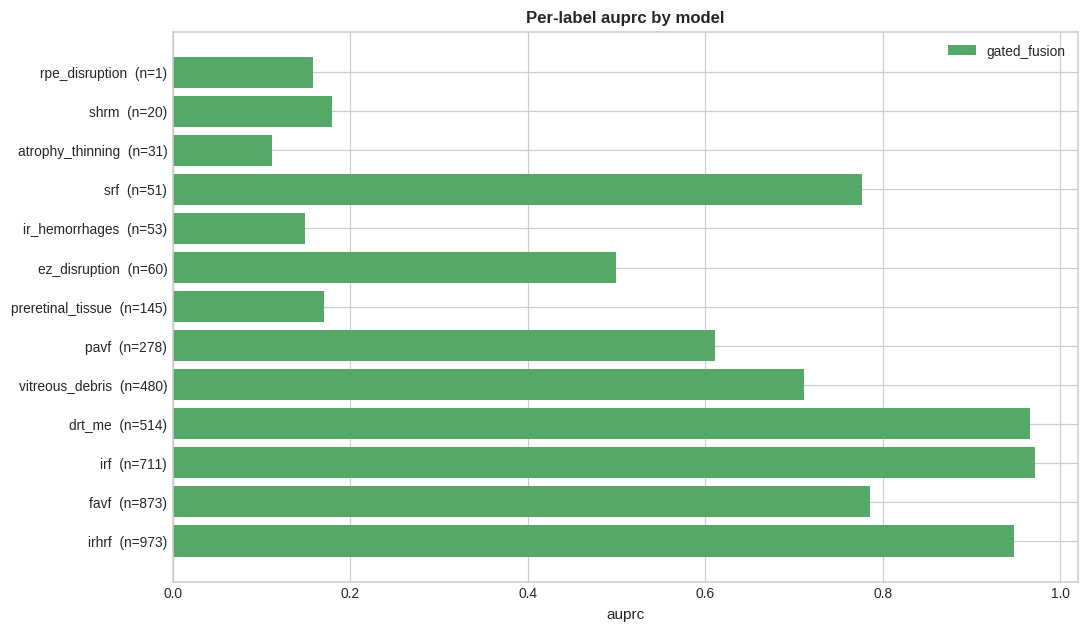

In [ ]:
pivot = aggregator.per_label_pivot(metric="auprc")
display(pivot)
show(plotter.per_label_comparison(pivot, metric="auprc"), "04_per_label_auprc")

In [ ]:
if {"concat_fusion", "gated_fusion"}.issubset(pivot.columns):
    delta = (pivot["gated_fusion"] - pivot["concat_fusion"]).sort_values(ascending=False)
    frame_delta = delta.to_frame("auprc_gain_over_concat")
    frame_delta["n_positive"] = pivot["n_positive"]
    display(frame_delta)

    fluid = [c for c in ["irf", "drt_me", "srf"] if c in delta.index]
    vitreous = [c for c in ["pavf", "favf", "vitreous_debris"] if c in delta.index]
    if fluid and vitreous:
        print(f"\nmean gain on fluid biomarkers    {delta[fluid].mean():+.4f}")
        print(f"mean gain on vitreous biomarkers {delta[vitreous].mean():+.4f}")
        print("\nThe mechanistic story predicts the first is larger. If they are similar, the")
        print("gate is not doing what the hypothesis says it does, whatever the macro metric says.")

---
## 8. Findings

Fill this in from the numbers above rather than from expectation.

In [ ]:
print("PHASE 3 SUMMARY")
print("=" * 60)
print(f"Runs compared : {sorted({r.model_name for r in all_results})}")
print(f"Seeds         : {SEEDS}")
print(f"Budget        : {BUDGET} ({budget.training.epochs} epochs, {budget.data.image_size})")
print()
if {"concat_fusion", "gated_fusion"}.issubset(means.index):
    gain = means.loc["gated_fusion", "macro_auprc"] - means.loc["concat_fusion", "macro_auprc"]
    print(f"macro AUPRC, gated - concat : {gain:+.4f}")
print(f"gate moved from identity by : {summary['mean_absolute_deviation_from_identity']:.4f}")
print(f"gate channels ~constant      : {100 * summary['fraction_channels_essentially_constant']:.0f}%")
print()
print("Verdict is only supportable once Phase 5 shows the confidence intervals separate.")

PHASE 3 SUMMARY
Runs compared : ['gated_fusion']
Seeds         : [42, 43, 44]
Budget        : colab_gpu (50 epochs, (224, 224))

gate moved from identity by : 0.9109
gate channels ~constant      : 20%

Verdict is only supportable once Phase 5 shows the confidence intervals separate.


### What to conclude, honestly

Model D is only supported if **all** of the following hold:

1. It beats Model C on macro AUPRC, and
2. the intervals separate under patient-level bootstrap (Phase 5), across seeds, and
3. the gate demonstrably moved off identity and varies with the clinical input, and
4. the gains concentrate where the mechanism predicts (fluid biomarkers), not uniformly.

If (1) holds but (3) does not, the honest reading is that the extra parameters helped, not the
gating mechanism — and the paper claim has to be written that way.

If none hold, that is a clean negative result: with one CST value shared across all 49 B-scans of
a visit, clinical features may simply have no conditional signal left once the image is present.
The EDA flagged that ceiling in advance, which is what makes the negative result credible rather
than a failed experiment.

**Next:** `04_uncertainty_calibration.ipynb`.